# Descriptive analysis of the FNF student survey

This notebook produces the first-pass descriptive results for the cleaned student survey. It covers:

1. sample composition and data completeness;
2. demographics, education and migration plans;
3. political interest, voting and civic participation;
4. views on political stability in Nepal;
5. views on Nepal's Gen-Z protest; and
6. views on protest and political stability in South Asia.


## Conventions

- The analysis population is exactly the set of observations in `student_survey_cleaned.dta`.
- Percentages use the number of non-missing responses to each item as the denominator.
- Empty strings are treated as missing. For routed follow-ups, these are normally question skips.
- In 1-to-5 ordered batteries, codes 1 and 2 are shown as the **top two** responses. Depending on the question, that means agreement, stability, likelihood, optimism, attention, or confidence.
- Means retain the questionnaire's original direction: lower values generally indicate stronger agreement or a more positive/likely assessment. Non-substantive responses (for example, “prefer not to say” or “don't know”) are excluded from ordered-scale means and top-two percentages.
- All results are unweighted and descriptive.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore", category=UserWarning, module="pandas.io.stata")

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.1f}")

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = ["#2667FF", "#6A4C93", "#2A9D8F", "#F4A261", "#E76F51", "#8AB17D", "#577590"]

In [2]:
def find_project_root(start=None):
    # Locate the project root whether run from the root or notebook folder.
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "1_data" / "2_clean" / "student_survey_cleaned.dta").exists():
            return candidate
    raise FileNotFoundError("Could not locate 1_data/2_clean/student_survey_cleaned.dta")


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "1_data" / "2_clean" / "student_survey_cleaned.dta"
OUTPUT_DIR = PROJECT_ROOT / "6_output" / "descriptive_analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Read once with value labels for presentation and once as numeric codes for
# ordered summaries. Variable labels provide readable question text.
df = pd.read_stata(DATA_PATH, convert_categoricals=True)
df_num = pd.read_stata(DATA_PATH, convert_categoricals=False)
stata_reader = pd.io.stata.StataReader(DATA_PATH)
variable_labels = stata_reader.variable_labels()

print(f"Data: {DATA_PATH.relative_to(PROJECT_ROOT)}")
print(f"Rows: {len(df):,} | Columns: {df.shape[1]:,}")
print(f"Interview dates: {df['interview_date'].min():%d %b %Y} to {df['interview_date'].max():%d %b %Y}")

Data: 1_data\2_clean\student_survey_cleaned.dta
Rows: 836 | Columns: 114
Interview dates: 23 Aug 2026 to 11 Sep 2026


## Helper functions

In [3]:
def clean_display_series(series):
    # Convert labelled categories to objects and standardize missing values.
    out = series.astype(object) if isinstance(series.dtype, pd.CategoricalDtype) else series.copy()
    if out.dtype == object:
        out = out.replace(r"^\s*$", np.nan, regex=True)
    # A few source variables retain -99 as an unlabelled refusal code.
    return out.replace({-99: "Prefer not to say", "-99": "Prefer not to say"})


def frequency_table(variable, data=df):
    # One-way frequency table using valid responses as the percent denominator.
    s = clean_display_series(data[variable])
    valid = s.dropna()
    counts = valid.value_counts(sort=False)
    result = pd.DataFrame({
        "variable": variable,
        "question": variable_labels.get(variable, variable),
        "response": counts.index.astype(str),
        "n": counts.to_numpy(),
        "percent_valid": (100 * counts.to_numpy() / len(valid)).round(1),
        "valid_n": len(valid),
        "missing_or_skip_n": len(s) - len(valid),
    })
    return result.reset_index(drop=True)


def grouped_frequency_table(variables):
    tables = [frequency_table(v) for v in variables if v in df.columns]
    return pd.concat(tables, ignore_index=True) if tables else pd.DataFrame()


def ordered_summary(variables, valid_codes=(1, 2, 3, 4, 5)):
    # Summarize ordered questionnaire items, excluding non-substantive codes.
    rows = []
    for variable in variables:
        s = pd.to_numeric(df_num[variable], errors="coerce")
        substantive = s[s.isin(valid_codes)]
        rows.append({
            "variable": variable,
            "item": re.sub(r"^[0-9.]+\s*", "", variable_labels.get(variable, variable)),
            "valid_n": int(substantive.size),
            "non_substantive_or_missing_n": int(len(s) - substantive.size),
            "mean_1_to_5": substantive.mean(),
            "sd": substantive.std(),
            "top_two_percent": 100 * substantive.isin([1, 2]).mean(),
            "neutral_percent": 100 * (substantive == 3).mean(),
            "bottom_two_percent": 100 * substantive.isin([4, 5]).mean(),
        })
    return pd.DataFrame(rows).round(1)


def yes_share_summary(variables):
    # Summarize yes/no items; code 1 is Yes and code 2 is No.
    rows = []
    for variable in variables:
        s = pd.to_numeric(df_num[variable], errors="coerce")
        substantive = s[s.isin([1, 2])]
        rows.append({
            "variable": variable,
            "item": re.sub(r"^[0-9.]+\s*", "", variable_labels.get(variable, variable)),
            "valid_n": int(substantive.size),
            "missing_or_other_n": int(len(s) - substantive.size),
            "yes_n": int((substantive == 1).sum()),
            "yes_percent": 100 * (substantive == 1).mean(),
        })
    return pd.DataFrame(rows).round(1)


NOT_VOTE_LABELS = {
    "1": "Did not register",
    "2": "Away from registered voting location",
    "3": "Health/family issue",
    "4": "Not interested in voting process",
    "5": "Did not trust political parties/candidates",
    "6": "Intentionally boycotted the election",
    "7": "Felt vote would make no difference",
    "8": "Prefer not to say",
    "9": "Other",
    "others_please_specify": "Other",
}


def coded_reason_table(variable, universe_variable):
    # Describe a coded follow-up among respondents whose parent item is No.
    raw = clean_display_series(df[variable]).dropna().astype(str).str.strip()
    raw = raw[raw.ne("")].replace(NOT_VOTE_LABELS)
    counts = raw.value_counts()
    universe = pd.to_numeric(df_num[universe_variable], errors="coerce").eq(2).sum()
    return pd.DataFrame({
        "reason": counts.index,
        "n": counts.values,
        "percent_of_no_voters": (100 * counts.values / universe).round(1),
        "no_voter_universe_n": int(universe),
    })


def plot_horizontal(summary, value, title, filename, xlabel=None, top_n=None):
    plot_data = summary.sort_values(value, ascending=True).copy()
    if top_n is not None:
        plot_data = plot_data.tail(top_n)
    height = max(3.5, 0.42 * len(plot_data))
    fig, ax = plt.subplots(figsize=(9, height))
    bars = ax.barh(plot_data["item"], plot_data[value], color=COLORS[0])
    ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=9)
    ax.set_title(title, loc="left", weight="bold")
    ax.set_xlabel(xlabel or value)
    ax.set_ylabel("")
    if "percent" in value:
        ax.set_xlim(0, 105)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / filename, dpi=160, bbox_inches="tight")
    plt.show()

## 1. Sample overview and completeness

In [4]:
sample_overview = pd.DataFrame({
    "measure": [
        "Interviews",
        "Earliest interview date",
        "Latest interview date",
        "Provinces represented",
        "Local governments represented",
        "Median age",
    ],
    "value": [
        f"{len(df):,}",
        f"{df['interview_date'].min():%d %b %Y}",
        f"{df['interview_date'].max():%d %b %Y}",
        str(clean_display_series(df['Province']).nunique(dropna=True)),
        str(clean_display_series(df['lg_name']).nunique(dropna=True)),
        f"{df_num['age'].median():.0f}",
    ],
})
display(sample_overview)

age_summary = df_num["age"].describe(percentiles=[0.25, 0.5, 0.75]).rename({
    "count": "Valid N", "mean": "Mean", "std": "SD", "min": "Minimum",
    "25%": "25th percentile", "50%": "Median", "75%": "75th percentile", "max": "Maximum",
}).to_frame("Age").round(1)
display(age_summary)

,measure,value
0,Interviews,836
1,Earliest interview date,23 Aug 2026
2,Latest interview date,11 Sep 2026
3,Provinces represented,7
4,Local governments represented,11
5,Median age,22


,Age
Valid N,836.0
Mean,22.2
SD,2.6
Minimum,18.0
25th percentile,20.0
Median,22.0
75th percentile,23.0
Maximum,34.0


In [5]:
substantive_variables = [
    c for c in df.columns
    if c not in {
        "interview_date", "interview_time", "Interviewer_Name", "local_government",
        "local_government_clean", "lg_review", "lg_review_note", "ward", "age",
        "Others_Please_Specify", "Others_please_specify_001", "Others_please_specify_002",
    }
]

completeness = pd.DataFrame({
    "variable": substantive_variables,
    "question": [variable_labels.get(v, v) for v in substantive_variables],
    "valid_n": [clean_display_series(df[v]).notna().sum() for v in substantive_variables],
})
completeness["missing_or_skip_n"] = len(df) - completeness["valid_n"]
completeness["percent_present"] = (100 * completeness["valid_n"] / len(df)).round(1)

display(completeness.sort_values(["percent_present", "variable"]).head(20))
print("The lowest-coverage variables are expected to be routed follow-ups; inspect their valid denominators below.")

,variable,question,valid_n,missing_or_skip_n,percent_present
8,edu_masters,1.3.4 Master's or higher institution: private ...,64,772,7.7
29,q2_7_1,2.7.1 Reason unlikely to vote in 2027 local el...,84,752,10.0
7,edu_bachelors,1.3.3 Bachelor's institution: private or public,93,743,11.1
24,q2_5,2.5 Voted in 2022 provincial election,228,608,27.3
17,abroad_purpose,1.10.1a Purpose of going abroad,309,527,37.0
15,family_returned,1.9.1 Family member abroad returned permanently,355,481,42.5
18,nepal_plan,1.10.1b Plans while staying in Nepal,421,415,50.4
22,q2_4,2.4 Voted in 2022 federal election,460,376,55.0
26,q2_6,2.6 Voted in 2022 local election,460,376,55.0
11,religion,Religion,822,14,98.3


The lowest-coverage variables are expected to be routed follow-ups; inspect their valid denominators below.


## 2. Demographics, education and migration

In [6]:
demographic_vars = [
    "gender", "education", "Province", "lg_type", "lg_name", "ethnicity",
    "religious_belief", "religion", "marital_status", "life_place",
    "edu_school", "edu_plus2", "edu_bachelors", "edu_masters",
]
demographic_table = grouped_frequency_table(demographic_vars)
display(demographic_table)

,variable,question,response,n,percent_valid,valid_n,missing_or_skip_n
0,gender,1.2 Gender,Female,385,46.1,836,0
1,gender,1.2 Gender,Male,451,53.9,836,0
2,education,1.3 Current education level and year,Bachelors 2nd year,178,21.3,836,0
3,education,1.3 Current education level and year,Bachelors 1st year,155,18.5,836,0
4,education,1.3 Current education level and year,Bachelors 4th year,182,21.8,836,0
5,education,1.3 Current education level and year,Bachelors 3rd year,212,25.4,836,0
6,education,1.3 Current education level and year,Bachelors 5th year,16,1.9,836,0
7,education,1.3 Current education level and year,Masters 1st year,63,7.5,836,0
8,education,1.3 Current education level and year,Masters 2nd year,29,3.5,836,0
9,education,1.3 Current education level and year,PHD,1,0.1,836,0


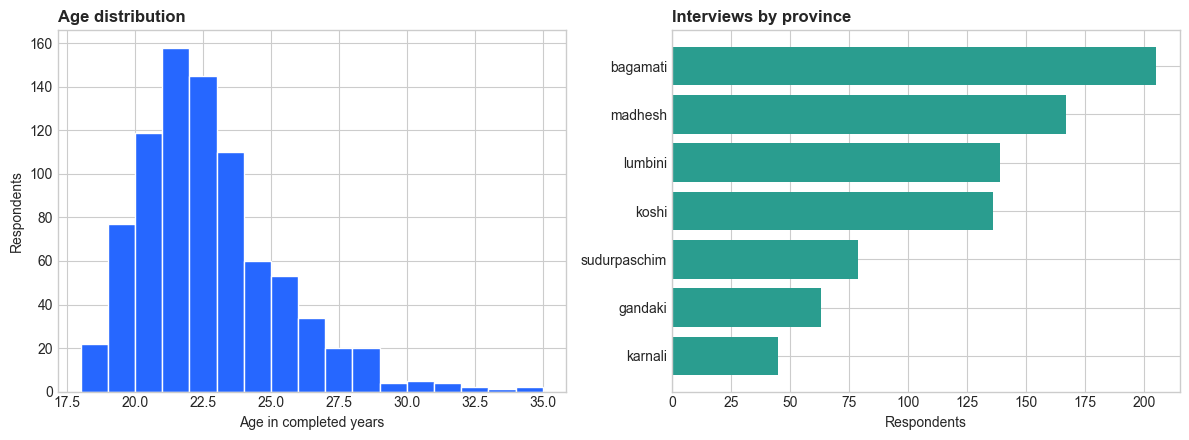

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(df_num["age"].dropna(), bins=range(int(df_num["age"].min()), int(df_num["age"].max()) + 2),
             color=COLORS[0], edgecolor="white")
axes[0].set_title("Age distribution", loc="left", weight="bold")
axes[0].set_xlabel("Age in completed years")
axes[0].set_ylabel("Respondents")

province_counts = clean_display_series(df["Province"]).value_counts().sort_values()
axes[1].barh(province_counts.index.astype(str), province_counts.values, color=COLORS[2])
axes[1].set_title("Interviews by province", loc="left", weight="bold")
axes[1].set_xlabel("Respondents")
axes[1].set_ylabel("")

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "sample_composition.png", dpi=160, bbox_inches="tight")
plt.show()

In [8]:
migration_vars = ["family_abroad", "family_returned", "migration_plan", "abroad_purpose", "nepal_plan"]
migration_table = grouped_frequency_table(migration_vars)
display(migration_table)

,variable,question,response,n,percent_valid,valid_n,missing_or_skip_n
0,family_abroad,1.9 Close family member has lived or lives abroad,No,481,57.5,836,0
1,family_abroad,1.9 Close family member has lived or lives abroad,Yes,355,42.5,836,0
2,family_returned,1.9.1 Family member abroad returned permanently,No,297,83.7,355,481
3,family_returned,1.9.1 Family member abroad returned permanently,Yes,57,16.1,355,481
4,family_returned,1.9.1 Family member abroad returned permanently,Not Sure,1,0.3,355,481
5,migration_plan,1.10 Plans to go abroad or stay in Nepal,Stay in Nepal,421,50.4,836,0
6,migration_plan,1.10 Plans to go abroad or stay in Nepal,Go Abroad,309,37.0,836,0
7,migration_plan,1.10 Plans to go abroad or stay in Nepal,Don't Know,106,12.7,836,0
8,abroad_purpose,1.10.1a Purpose of going abroad,Study and Work,172,55.7,309,527
9,abroad_purpose,1.10.1a Purpose of going abroad,Study,61,19.7,309,527


`family_returned`, `abroad_purpose`, and `nepal_plan` are conditional follow-ups. Their percentages therefore use only respondents who answered each follow-up, not the full sample.

## 3. Political interest, voting and civic participation

In [9]:
political_interest_vars = ["q2_1", "q2_2", "q2_3", "q2_7", "q2_7_1", "q2_9"]
political_interest_table = grouped_frequency_table(political_interest_vars)
display(political_interest_table)

,variable,question,response,n,percent_valid,valid_n,missing_or_skip_n
0,q2_1,2.1 Agreement: politics is central to living i...,Disagree,210,25.1,836,0
1,q2_1,2.1 Agreement: politics is central to living i...,Agree,234,28.0,836,0
2,q2_1,2.1 Agreement: politics is central to living i...,Neutral,148,17.7,836,0
3,q2_1,2.1 Agreement: politics is central to living i...,Strongly Agree,86,10.3,836,0
4,q2_1,2.1 Agreement: politics is central to living i...,Prefer not to say,12,1.4,836,0
5,q2_1,2.1 Agreement: politics is central to living i...,Strongly Disagree,146,17.5,836,0
6,q2_2,2.2 Frequency of following political news,Several times a week,211,25.2,836,0
7,q2_2,2.2 Frequency of following political news,Daily,446,53.3,836,0
8,q2_2,2.2 Frequency of following political news,Weekly,30,3.6,836,0
9,q2_2,2.2 Frequency of following political news,Never,13,1.6,836,0


In [10]:
voting_vars = ["q2_4", "q2_5", "q2_6"]
voting_table = grouped_frequency_table(voting_vars)
display(voting_table)

federal_nonvote_reasons = coded_reason_table("q2_4_1", "q2_4")
provincial_nonvote_reasons = coded_reason_table("q2_5_1", "q2_5")
local_nonvote_reasons = coded_reason_table("q2_6_1", "q2_6")

print("Federal election: reasons among respondents recorded as not voting")
display(federal_nonvote_reasons)
print("Provincial election: reasons among respondents recorded as not voting")
display(provincial_nonvote_reasons)
print("Local election: reasons among respondents recorded as not voting")
display(local_nonvote_reasons)

,variable,question,response,n,percent_valid,valid_n,missing_or_skip_n
0,q2_4,2.4 Voted in 2022 federal election,Yes,228,49.6,460,376
1,q2_4,2.4 Voted in 2022 federal election,No,224,48.7,460,376
2,q2_4,2.4 Voted in 2022 federal election,Not Sure,8,1.7,460,376
3,q2_5,2.5 Voted in 2022 provincial election,Yes,217,95.2,228,608
4,q2_5,2.5 Voted in 2022 provincial election,No,10,4.4,228,608
5,q2_5,2.5 Voted in 2022 provincial election,Not Sure,1,0.4,228,608
6,q2_6,2.6 Voted in 2022 local election,Yes,222,48.3,460,376
7,q2_6,2.6 Voted in 2022 local election,No,228,49.6,460,376
8,q2_6,2.6 Voted in 2022 local election,Not Sure,10,2.2,460,376


Federal election: reasons among respondents recorded as not voting


,reason,n,percent_of_no_voters,no_voter_universe_n
0,Did not register,161,71.9,224
1,Health/family issue,31,13.8,224
2,Intentionally boycotted the election,7,3.1,224
3,Other,6,2.7,224
4,Did not trust political parties/candidates,6,2.7,224
5,Not interested in voting process,5,2.2,224
6,Felt vote would make no difference,4,1.8,224
7,Prefer not to say,4,1.8,224


Provincial election: reasons among respondents recorded as not voting


,reason,n,percent_of_no_voters,no_voter_universe_n
0,Did not register,4,40.0,10
1,Did not trust political parties/candidates,2,20.0,10
2,Health/family issue,2,20.0,10
3,Not interested in voting process,2,20.0,10


Local election: reasons among respondents recorded as not voting


,reason,n,percent_of_no_voters,no_voter_universe_n
0,Did not register,160,70.2,228
1,Health/family issue,36,15.8,228
2,Other,8,3.5,228
3,Not interested in voting process,6,2.6,228
4,Did not trust political parties/candidates,6,2.6,228
5,Intentionally boycotted the election,5,2.2,228
6,Prefer not to say,4,1.8,228
7,Felt vote would make no difference,3,1.3,228


Voting items were routed by age in the questionnaire, and the provincial item also has a narrower observed denominator in the current cleaned file. Blank follow-up reasons are retained as missing rather than recoded.

,variable,item,valid_n,missing_or_other_n,yes_n,yes_percent
0,q2_8_1,Past 12 months: Attended campaign/rally,836,0,175,20.9
1,q2_8_2,Past 12 months: Volunteered for party/campaign,836,0,89,10.6
2,q2_8_3,Past 12 months: Joined protest/demonstration,836,0,246,29.4
3,q2_8_4,Past 12 months: Joined public meeting/discussion,836,0,265,31.7
4,q2_8_5,Past 12 months: Contacted elected representative,836,0,169,20.2
5,q2_8_6,Past 12 months: Joined ward user committee,836,0,37,4.4


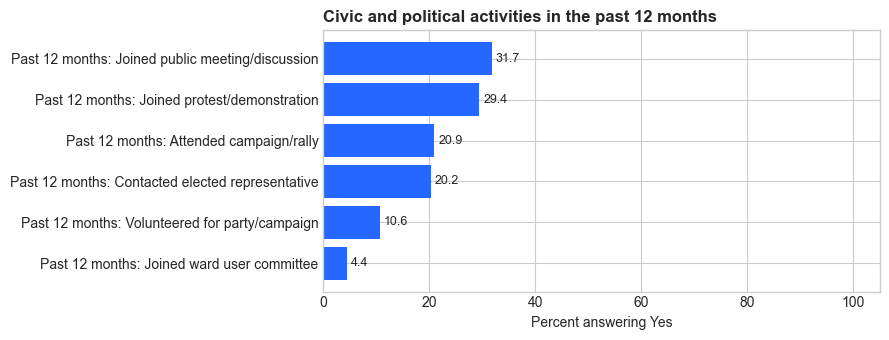

In [11]:
civic_vars = [f"q2_8_{i}" for i in range(1, 7)]
civic_summary = yes_share_summary(civic_vars)
display(civic_summary)

plot_horizontal(
    civic_summary,
    "yes_percent",
    "Civic and political activities in the past 12 months",
    "civic_participation.png",
    xlabel="Percent answering Yes",
)

## 4. Political stability in Nepal

,variable,item,valid_n,non_substantive_or_missing_n,mean_1_to_5,sd,top_two_percent,neutral_percent,bottom_two_percent
3,q3_1_3,Nepal instability cause: Corruption,833,3,1.5,0.7,95.9,2.4,1.7
2,q3_1_2_001,Nepal instability cause: Policy implementation...,833,3,1.6,0.7,93.9,4.1,2.0
0,q3_1_1,Nepal instability cause: Government changes/pa...,830,6,1.6,0.7,93.0,4.7,2.3
1,q3_1_2,Nepal instability cause: Policy formulation fa...,835,1,1.7,0.8,92.8,3.2,4.0
4,q3_1_3_001,Nepal instability cause: Lack of accountability,834,2,1.7,0.7,92.1,5.6,2.3
5,q3_1_4,Nepal instability cause: Protests/violence/civ...,834,2,1.7,0.8,89.6,6.2,4.2
7,q3_1_6,Nepal instability cause: Conflict between gove...,835,1,1.8,0.7,89.0,7.1,4.0
8,q3_1_7,Nepal instability cause: Foreign/external infl...,825,11,2.1,0.9,76.0,15.3,8.7
6,q3_1_5,Nepal instability cause: Transfers of governme...,833,3,2.4,1.1,63.9,18.0,18.1


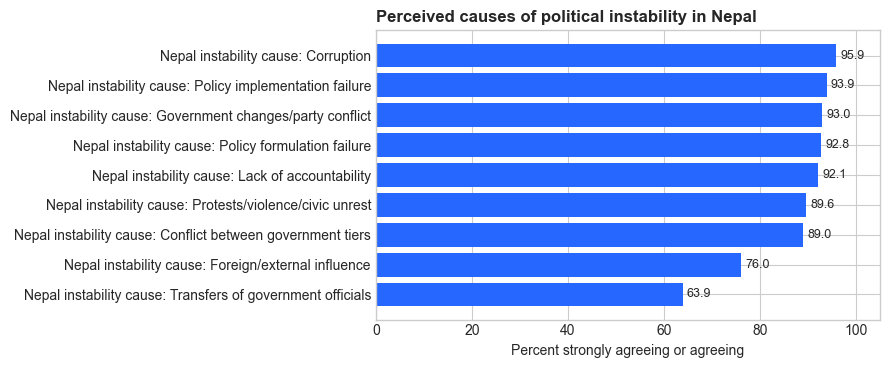

In [12]:
instability_cause_vars = [
    "q3_1_1", "q3_1_2", "q3_1_2_001", "q3_1_3", "q3_1_3_001",
    "q3_1_4", "q3_1_5", "q3_1_6", "q3_1_7",
]
instability_causes = ordered_summary(instability_cause_vars)
display(instability_causes.sort_values("top_two_percent", ascending=False))

plot_horizontal(
    instability_causes,
    "top_two_percent",
    "Perceived causes of political instability in Nepal",
    "nepal_instability_causes.png",
    xlabel="Percent strongly agreeing or agreeing",
)

In [13]:
nepal_outlook_vars = ["q3_2", "q3_3", "q3_4", "q3_5", "q3_6", "q3_7", "q3_8", "q3_9"]
nepal_outlook_table = grouped_frequency_table(nepal_outlook_vars)
display(nepal_outlook_table)

,variable,question,response,n,percent_valid,valid_n,missing_or_skip_n
0,q3_2,3.2 Political stability of Nepal today,Neutral,184,22.0,836,0
1,q3_2,3.2 Political stability of Nepal today,Stable,454,54.3,836,0
2,q3_2,3.2 Political stability of Nepal today,Very Stable,43,5.1,836,0
3,q3_2,3.2 Political stability of Nepal today,Prefer not to say,10,1.2,836,0
4,q3_2,3.2 Political stability of Nepal today,Unstable,119,14.2,836,0
5,q3_2,3.2 Political stability of Nepal today,Very Unstable,26,3.1,836,0
6,q3_3,3.3 Nepal stability compared with one year ago,About the same,135,16.1,836,0
7,q3_3,3.3 Nepal stability compared with one year ago,Somewhat more stable,564,67.5,836,0
8,q3_3,3.3 Nepal stability compared with one year ago,Somewhat less stable,47,5.6,836,0
9,q3_3,3.3 Nepal stability compared with one year ago,Much more stable,58,6.9,836,0


,variable,item,valid_n,non_substantive_or_missing_n,mean_1_to_5,sd,top_two_percent,neutral_percent,bottom_two_percent
0,q3_10_11,Nepal stability risk: Corruption,834,2,1.4,0.6,96.0,2.2,1.8
2,q3_10_12,Nepal stability risk: Unemployment/economic op...,835,1,1.5,0.7,94.6,3.2,2.2
1,q3_10_11_001,Nepal stability risk: Lack of accountability,835,1,1.6,0.7,94.1,4.3,1.6
4,q3_10_14,Nepal stability risk: Rising cost of living,835,1,1.8,0.8,88.1,7.5,4.3
7,q3_10_17,Nepal stability risk: Ethnic/religious conflict,834,2,1.8,0.8,88.0,6.7,5.3
3,q3_10_13,Nepal stability risk: Political exclusion,834,2,1.8,0.7,87.4,9.8,2.8
5,q3_10_15,Nepal stability risk: Social media misinformation,836,0,1.8,0.8,84.1,11.0,4.9
6,q3_10_16,Nepal stability risk: Foreign/external influence,828,8,2.0,0.9,79.7,13.9,6.4


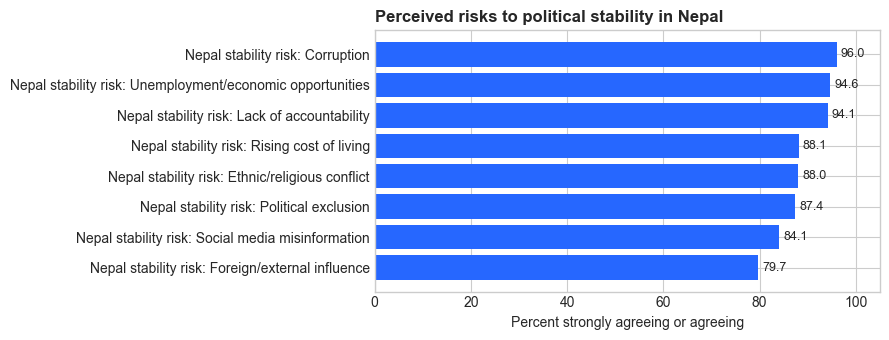

In [14]:
nepal_risk_vars = [
    "q3_10_11", "q3_10_11_001", "q3_10_12", "q3_10_13",
    "q3_10_14", "q3_10_15", "q3_10_16", "q3_10_17",
]
nepal_risks = ordered_summary(nepal_risk_vars)
display(nepal_risks.sort_values("top_two_percent", ascending=False))

plot_horizontal(
    nepal_risks,
    "top_two_percent",
    "Perceived risks to political stability in Nepal",
    "nepal_stability_risks.png",
    xlabel="Percent strongly agreeing or agreeing",
)

In [15]:
nepal_hope_vars = ["q3_11_1", "q3_11_2", "q3_11_3", "q3_11_4"]
nepal_hopes = ordered_summary(nepal_hope_vars)
display(nepal_hopes.sort_values("top_two_percent", ascending=False))

,variable,item,valid_n,non_substantive_or_missing_n,mean_1_to_5,sd,top_two_percent,neutral_percent,bottom_two_percent
1,q3_11_2,Nepal hope: Youth political participation,828,8,1.9,0.8,82.2,14.3,3.5
0,q3_11_1,Nepal hope: Governance/anti-corruption reforms,828,8,2.3,1.0,69.8,18.7,11.5
2,q3_11_3,Nepal hope: Improved democracy,827,9,2.3,0.9,67.1,23.3,9.6
3,q3_11_4,Nepal hope: Economic/employment prospects,826,10,2.5,1.1,58.4,22.0,19.6


## 5. Nepal's Gen-Z protest

,variable,question,response,n,percent_valid,valid_n,missing_or_skip_n
0,q4_1,4.1 Attention to September 8 Gen-Z protest and...,Somewhat Closely,116,13.9,836,0
1,q4_1,4.1 Attention to September 8 Gen-Z protest and...,Very Closely,477,57.1,836,0
2,q4_1,4.1 Attention to September 8 Gen-Z protest and...,Engaged Directly,224,26.8,836,0
3,q4_1,4.1 Attention to September 8 Gen-Z protest and...,Not at All,4,0.5,836,0
4,q4_1,4.1 Attention to September 8 Gen-Z protest and...,Heard But followed Vary Little,15,1.8,836,0


,variable,item,valid_n,non_substantive_or_missing_n,mean_1_to_5,sd,top_two_percent,neutral_percent,bottom_two_percent
0,q4_2_1,Gen-Z protest cause: Corruption,834,2,1.5,0.8,93.8,2.6,3.6
4,q4_2_5,Gen-Z protest cause: Distrust of leaders/parti...,834,2,1.6,0.8,90.2,6.6,3.2
5,q4_2_6,Gen-Z protest cause: Nepotism/elite capture,832,4,1.6,0.8,89.2,6.7,4.1
2,q4_2_3,Gen-Z protest cause: Unemployment/economic opp...,836,0,1.8,0.9,85.2,7.1,7.8
1,q4_2_2,Gen-Z protest cause: Poor public services,831,5,1.8,0.8,85.0,9.9,5.2
6,q4_2_7,Gen-Z protest cause: Social media ban,834,2,1.8,1.0,80.6,11.5,7.9
3,q4_2_4,Gen-Z protest cause: Rising cost of living,835,1,2.4,1.2,63.2,14.6,22.2
7,q4_2_8,Gen-Z protest cause: Foreign/external influence,818,18,2.7,1.3,49.4,18.9,31.7


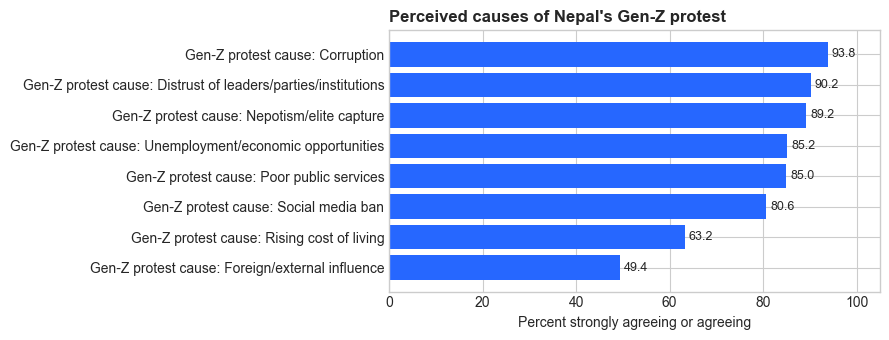

In [16]:
genz_attention_table = frequency_table("q4_1")
display(genz_attention_table)

genz_cause_vars = [f"q4_2_{i}" for i in range(1, 9)]
genz_causes = ordered_summary(genz_cause_vars)
display(genz_causes.sort_values("top_two_percent", ascending=False))

plot_horizontal(
    genz_causes,
    "top_two_percent",
    "Perceived causes of Nepal's Gen-Z protest",
    "genz_protest_causes.png",
    xlabel="Percent strongly agreeing or agreeing",
)

In [17]:
genz_consequence_vars = ["q4_3", "q4_4", "q4_5", "q4_6", "q4_7", "q4_8"]
genz_consequences = ordered_summary(genz_consequence_vars)
display(genz_consequences.sort_values("top_two_percent", ascending=False))

,variable,item,valid_n,non_substantive_or_missing_n,mean_1_to_5,sd,top_two_percent,neutral_percent,bottom_two_percent
3,q4_6,Gen-Z protest: increased public support for RSP,831,5,1.7,0.7,91.9,6.1,1.9
0,q4_3,Gen-Z protest: turning point in political history,833,3,1.6,0.7,91.8,6.2,1.9
1,q4_4,Gen-Z protest: greater youth civic/political p...,832,4,1.7,0.7,91.2,5.9,2.9
2,q4_5,Gen-Z protest: youth voices included in mainst...,830,6,1.9,0.8,84.6,9.9,5.5
4,q4_7,Current government represents youth interests,829,7,2.0,0.9,77.9,16.4,5.7
5,q4_8,Government will continue to advance youth inte...,822,14,2.0,0.9,76.8,17.3,6.0


## 6. Protest and political stability in South Asia

In [18]:
south_asia_overview_vars = ["q5_1", "q5_3", "q5_4", "q5_5"]
south_asia_overview = grouped_frequency_table(south_asia_overview_vars)
display(south_asia_overview)

south_asia_cause_vars = [f"q5_2_{i}" for i in range(1, 7)]
south_asia_causes = ordered_summary(south_asia_cause_vars)
display(south_asia_causes.sort_values("top_two_percent", ascending=False))

,variable,question,response,n,percent_valid,valid_n,missing_or_skip_n
0,q5_1,5.1 Attention to protests in other Asian count...,Not Very Closely,339,40.6,836,0
1,q5_1,5.1 Attention to protests in other Asian count...,Somewhat Closely,323,38.6,836,0
2,q5_1,5.1 Attention to protests in other Asian count...,Not at all,99,11.8,836,0
3,q5_1,5.1 Attention to protests in other Asian count...,Very Closely,74,8.9,836,0
4,q5_1,5.1 Attention to protests in other Asian count...,Prefer not to say,1,0.1,836,0
5,q5_3,5.3 Protests in one country encourage others i...,Neutral,103,12.3,836,0
6,q5_3,5.3 Protests in one country encourage others i...,Strongly Agree,252,30.1,836,0
7,q5_3,5.3 Protests in one country encourage others i...,Prefer not to say,23,2.8,836,0
8,q5_3,5.3 Protests in one country encourage others i...,Disagree,71,8.5,836,0
9,q5_3,5.3 Protests in one country encourage others i...,Agree,364,43.5,836,0


,variable,item,valid_n,non_substantive_or_missing_n,mean_1_to_5,sd,top_two_percent,neutral_percent,bottom_two_percent
0,q5_2_1,South Asia dissent cause: Governance/corruptio...,779,57,1.8,0.7,89.1,7.1,3.9
1,q5_2_2,South Asia dissent cause: Unemployment/economi...,772,64,1.9,0.7,89.0,7.0,4.0
2,q5_2_3,South Asia dissent cause: Distrust of leaders/...,756,80,1.8,0.7,87.0,10.1,2.9
4,q5_2_5,South Asia dissent cause: Nepotism/elite capture,758,78,1.9,0.8,84.2,10.9,4.9
3,q5_2_4,South Asia dissent cause: Political exclusion,745,91,2.2,0.9,71.5,18.4,10.1
5,q5_2_6,South Asia dissent cause: Foreign/external inf...,745,91,2.2,0.9,70.1,18.9,11.0


,variable,item,valid_n,non_substantive_or_missing_n,mean_1_to_5,sd,top_two_percent,neutral_percent,bottom_two_percent
0,q5_6_1,South Asia stability risk: Corruption/lack of ...,807,29,1.8,0.7,90.6,7.6,1.9
1,q5_6_2,South Asia stability risk: Unemployment/econom...,807,29,1.8,0.7,90.3,7.6,2.1
2,q5_6_3,South Asia stability risk: Political exclusion,801,35,1.9,0.7,85.8,11.7,2.5
6,q5_6_7,South Asia stability risk: Ethnic/religious co...,808,28,1.8,0.8,85.8,10.5,3.7
3,q5_6_4,South Asia stability risk: Rising cost of living,810,26,1.9,0.8,84.1,12.8,3.1
4,q5_6_5,South Asia stability risk: Social media misinf...,809,27,1.9,0.8,82.6,14.5,3.0
5,q5_6_6,South Asia stability risk: Foreign/external in...,798,38,2.0,0.8,77.2,16.9,5.9


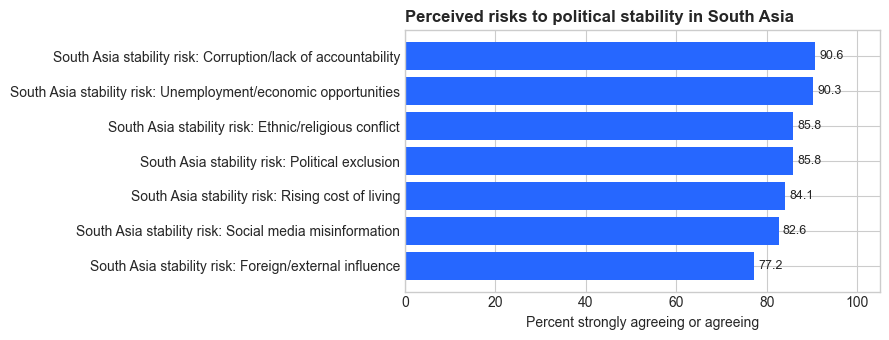

In [19]:
south_asia_risk_vars = [f"q5_6_{i}" for i in range(1, 8)]
south_asia_risks = ordered_summary(south_asia_risk_vars)
display(south_asia_risks.sort_values("top_two_percent", ascending=False))

plot_horizontal(
    south_asia_risks,
    "top_two_percent",
    "Perceived risks to political stability in South Asia",
    "south_asia_stability_risks.png",
    xlabel="Percent strongly agreeing or agreeing",
)

In [20]:
south_asia_hope_vars = [f"q5_7_{i}" for i in range(1, 5)]
south_asia_hopes = ordered_summary(south_asia_hope_vars)
display(south_asia_hopes.sort_values("top_two_percent", ascending=False))

,variable,item,valid_n,non_substantive_or_missing_n,mean_1_to_5,sd,top_two_percent,neutral_percent,bottom_two_percent
1,q5_7_2,South Asia hope: Youth political participation,773,63,2.1,0.7,79.3,16.2,4.5
0,q5_7_1,South Asia hope: Governance/anti-corruption re...,755,81,2.4,1.0,63.8,24.5,11.7
2,q5_7_3,South Asia hope: Improved democracy,763,73,2.4,0.8,63.8,26.5,9.7
3,q5_7_4,South Asia hope: Economic/employment prospects,763,73,2.5,1.0,59.8,24.4,15.9


## 7. Complete distributions and exported tables

In [21]:
# Complete one-way distributions for every substantive categorical item.
# Age is summarized separately above; open-ended text and administrative fields are excluded.
excluded_from_frequency_appendix = {
    "interview_date", "interview_time", "Interviewer_Name", "local_government",
    "local_government_clean", "lg_review", "lg_review_note", "ward", "age",
    "Others_Please_Specify", "Others_please_specify_001", "Others_please_specify_002",
    "q2_4_1", "q2_5_1", "q2_6_1",
}
frequency_appendix_vars = [c for c in df.columns if c not in excluded_from_frequency_appendix]
all_frequencies = grouped_frequency_table(frequency_appendix_vars)

print(f"Complete frequency appendix: {len(all_frequencies):,} rows across {all_frequencies['variable'].nunique():,} variables")
display(all_frequencies.head(40))
print("The complete table is saved in the Excel workbook below.")

Complete frequency appendix: 506 rows across 99 variables


,variable,question,response,n,percent_valid,valid_n,missing_or_skip_n
0,Province,Province,madhesh,167,20.0,834,2
1,Province,Province,koshi,136,16.3,834,2
2,Province,Province,gandaki,63,7.6,834,2
3,Province,Province,bagamati,205,24.6,834,2
4,Province,Province,karnali,45,5.4,834,2
5,Province,Province,lumbini,139,16.7,834,2
6,Province,Province,sudurpaschim,79,9.5,834,2
7,lg_name,Local government: standardized name,Janakpurdham,168,20.1,834,2
8,lg_name,Local government: standardized name,Biratnagar,135,16.2,834,2
9,lg_name,Local government: standardized name,Pokhara,68,8.2,834,2


The complete table is saved in the Excel workbook below.


In [22]:
workbook_path = OUTPUT_DIR / "descriptive_tables.xlsx"

with pd.ExcelWriter(workbook_path, engine="openpyxl") as writer:
    sample_overview.to_excel(writer, sheet_name="sample_overview", index=False)
    age_summary.to_excel(writer, sheet_name="age_summary")
    completeness.to_excel(writer, sheet_name="completeness", index=False)
    demographic_table.to_excel(writer, sheet_name="demographics", index=False)
    migration_table.to_excel(writer, sheet_name="migration", index=False)
    political_interest_table.to_excel(writer, sheet_name="political_interest", index=False)
    voting_table.to_excel(writer, sheet_name="voting", index=False)
    federal_nonvote_reasons.to_excel(writer, sheet_name="federal_nonvote", index=False)
    provincial_nonvote_reasons.to_excel(writer, sheet_name="provincial_nonvote", index=False)
    local_nonvote_reasons.to_excel(writer, sheet_name="local_nonvote", index=False)
    civic_summary.to_excel(writer, sheet_name="civic_participation", index=False)
    instability_causes.to_excel(writer, sheet_name="nepal_causes", index=False)
    nepal_outlook_table.to_excel(writer, sheet_name="nepal_outlook", index=False)
    nepal_risks.to_excel(writer, sheet_name="nepal_risks", index=False)
    nepal_hopes.to_excel(writer, sheet_name="nepal_hopes", index=False)
    genz_attention_table.to_excel(writer, sheet_name="genz_attention", index=False)
    genz_causes.to_excel(writer, sheet_name="genz_causes", index=False)
    genz_consequences.to_excel(writer, sheet_name="genz_consequences", index=False)
    south_asia_overview.to_excel(writer, sheet_name="south_asia_overview", index=False)
    south_asia_causes.to_excel(writer, sheet_name="south_asia_causes", index=False)
    south_asia_risks.to_excel(writer, sheet_name="south_asia_risks", index=False)
    south_asia_hopes.to_excel(writer, sheet_name="south_asia_hopes", index=False)
    all_frequencies.to_excel(writer, sheet_name="all_frequencies", index=False)

print(f"Saved tables to: {workbook_path.relative_to(PROJECT_ROOT)}")
print(f"Saved figures to: {OUTPUT_DIR.relative_to(PROJECT_ROOT)}")

Saved tables to: 6_output\descriptive_analysis\descriptive_tables.xlsx
Saved figures to: 6_output\descriptive_analysis


## Reading the first-pass results

The ranked battery tables and charts are intended for quick inspection. Before any inferential analysis, the next decisions should be whether to apply sampling weights, how to treat the cleaned file's routing anomalies, and which subgroup comparisons are substantively important. The complete frequency appendix preserves the item-level distributions needed for those decisions.